In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import os

import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms

import torch.nn.functional as F


In [59]:

class CreditCardDataset(Dataset):
    """
    Custom Dataset for loading credit card images and their corresponding labels.
    This class handles the mapping of text characters to integers for CTC Loss.
    """
    def __init__(self, img_dir, label_dir, img_height=128, img_width=64, transform=None):
        """
        Args:
            img_dir (str): Path to the folder containing images.
            label_dir (str): Path to the folder containing text labels.
            img_height (int): Target height for the image resizing (standard for CRNN is 32).
            img_width (int): Target width for the image.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.img_dir = img_dir
        self.label_dir = label_dir


        if not os.path.isdir(img_dir):
            raise FileNotFoundError(f"Image directory not found: {img_dir}")
        if not os.path.isdir(label_dir):
            raise FileNotFoundError(f"Label directory not found: {label_dir}")

        self.image_files = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))]


        self.chars = "0123456789"


        self.char_to_idx = {char: idx  for idx, char in enumerate(self.chars)}
        self.idx_to_char = {idx : char for idx, char in enumerate(self.chars)}


        if transform is None:
            self.transform = transforms.Compose([
                transforms.Grayscale(num_output_channels=1),
                transforms.Resize((img_height, img_width)),
                transforms.ToTensor(),
                transforms.Normalize((0.5,), (0.5,))
            ])
        else:
            self.transform = transform

    def encode_label(self, text):
        """
        Converts a string (e.g., "4580") into a list of integers based on the mapping.
        Removes spaces from the credit card number.
        """
        # Remove spaces as we only want to predict the digits
        clean_text = text.replace(" ", "").strip()

        encoded = []
        for char in clean_text:
            if char in self.char_to_idx:
                encoded.append(self.char_to_idx[char])

        return torch.tensor(encoded, dtype=torch.long)

    def __len__(self):
        # Returns the total number of samples
        return len(self.image_files)

    def __getitem__(self, idx):

        img_name = self.image_files[idx]
        img_path = os.path.join(self.img_dir, img_name)


        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_path = os.path.join(self.label_dir, label_name)


        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
        except Exception as e:
            print(f"Error loading image {img_name}: {e}")
            return None


        try:
            with open(label_path, 'r') as f:
                text_label = f.read().strip()
        except Exception as e:
            print(f"Error loading label {label_name}: {e}")
            return None


        encoded_label = self.encode_label(text_label)


        return {
            'image': image,
            'label': encoded_label,


        }

In [147]:
dif=False

In [77]:


# Install gdown to download files from Google Drive
!pip install gdown

# Google Drive file ID for the zip file
#1dataset
file_id = '130JFvPdjM3jJbuKQLqNWjT3_SapjMVuw'
#2dataset
#file_id='1Po4drHZdgKPnC2hCVwUJ8d4-hJ8VuujB'
output_filename = 'dataset.zip'

# Download the zip file
!gdown --id {file_id} -O {output_filename}

# Create the target directory in Colab's local file system

# Unzip the file to a temporary location first
!unzip -q {output_filename} -d /content/



/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=130JFvPdjM3jJbuKQLqNWjT3_SapjMVuw
From (redirected): https://drive.google.com/uc?id=130JFvPdjM3jJbuKQLqNWjT3_SapjMVuw&confirm=t&uuid=78065bef-c439-418c-a159-8e63818d4b1f
To: /content/dataset.zip
100% 42.0M/42.0M [00:00<00:00, 77.9MB/s]


In [148]:
if dif:
  img_dir_colab = "/content/final_augmented_dataset/images"
  label_dir_colab = "/content/final_augmented_dataset/labels"
else:
  img_dir_colab = "/content/dataset/images"
  label_dir_colab = "/content/dataset/labels"



try:
    dataset = CreditCardDataset(img_dir=img_dir_colab, label_dir=label_dir_colab,img_height=64,img_width=128)
    if len(dataset) > 0:
        sample = dataset[0]
        print(f"Encoded Label: {sample['label']}")
        print(f"Image Shape: {sample['image'].shape}")
    else:
        print("No image files found in the specified directory. Please ensure your images are uploaded.")
except FileNotFoundError as e:
    print(f"Error: {e}. Please ensure you have uploaded your 'images' and 'labels' folders correctly and updated the paths.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Encoded Label: tensor([8, 9, 4, 1, 4, 3, 5, 6, 1, 1, 7, 0, 3, 6, 3, 9])
Image Shape: torch.Size([1, 64, 128])


In [149]:



class MOCNN(nn.Module):

    def __init__(self, img_channel, num_class,num_digit):
        super(MOCNN, self).__init__()


        self.cnn_layer1 = nn.Sequential(
            nn.Conv2d(in_channels=img_channel, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 2), stride=2) # Downsample H and W by 2 (H=32, W=64)
        )


        self.cnn_layer2 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 2),stride=2) # Downsample H and W by 2 (H=16, W=32)
        )


        self.cnn_layer3 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), # Batch Norm helps with faster convergence
            nn.ReLU(inplace=True)
        )


        self.cnn_layer4 = nn.Sequential(
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 2),stride=2) # Downsample H only (H=8, W=16)
        )

        self.cnn_layer5 = nn.Sequential(
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)) # Downsample H only (H=4, W=16)
        )




        self.cnn_layer6 = nn.Sequential(
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)), # Downsample H only (H=2, w=16)
            nn.MaxPool2d(kernel_size=(2, 1)), # Downsample H only (H=1, w=16)

        )

        self.cnn_layer7 = nn.Sequential(
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)), # Downsample H only (H=2, w=16)
            nn.MaxPool2d(kernel_size=(2, 1)), # Downsample H only (H=1, w=16)
        )


        self.embedding = nn.Sequential(nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_class)
        )


        self.num_digit=num_digit

    def forward(self, x):

        x = self.cnn_layer1(x)
        #print(x.shape)
        x = self.cnn_layer2(x)
        #print(x.shape)
        x = self.cnn_layer3(x)
        #print(x.shape)
        x = self.cnn_layer4(x)
        #print(x.shape)
        x = self.cnn_layer5(x)
        #print(x.shape)
        x = self.cnn_layer6(x)
        #print(x.shape)
        #x=self.cnn_layer7(x)
        conv_out = x.squeeze(2) # Shape: (Batch, 512, Width_New)

        conv_out = conv_out.permute(0, 2, 1)
        #print(conv_out.shape)
        output=self.embedding(conv_out)
        #print(output.shape)


        return output



In [150]:



def credit_card_collate_fn(batch):

    batch = [item for item in batch if item is not None]

    images = [item['image'] for item in batch]
    labels = [item['label'] for item in batch]



    images = torch.stack(images, 0)


    targets = pad_sequence(labels, batch_first=True, padding_value=0)



    return images, targets


In [153]:


def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=50, device='cuda',eval=False):
    print(f"Starting training on {device}...")
    model = model.to(device)

    # Lists to store metrics for plotting
    loss_train = []
    loss_val = []

    for epoch in range(num_epochs):
        # --- Training Phase ---
        model.train()
        running_train_loss = 0.0

        for batch_idx, (images, targets) in enumerate(train_loader):
            images = images.to(device)
            targets = targets.to(device)

            # Forward pass
            preds = model(images)

            # Calculate loss for multi-head output
            preds=preds.permute(0,2,1)
            loss=criterion(preds,targets)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()

            # Gradient clipping (optional but good for stability)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)

            optimizer.step()

            running_train_loss += loss.item()


        # Calculate average training loss for the epoch
        avg_train_loss = running_train_loss / len(train_loader)
        loss_train.append(avg_train_loss)

        # --- Validation Phase ---
        if eval:
            model.eval()
            running_val_loss = 0.0

            with torch.no_grad():
                # Iterate over the ENTIRE validation loader, not just one batch
                for images, targets in val_loader:
                    images = images.to(device)
                    targets = targets.to(device)

                    preds = model(images)

                    preds=preds.permute(0,2,1)
                    total_loss = criterion(preds, targets)


                    running_val_loss += total_loss.item()

                    # Calculate average validation loss for the epoch
                avg_val_loss = running_val_loss / len(val_loader)
                loss_val.append(avg_val_loss)

                print(f"End of Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f}, Val Loss:{avg_val_loss:.4f} ")

    # --- Plotting the Results ---
    plt.figure(figsize=(10, 5))
    plt.plot(loss_train, label='Training Loss')
    plt.plot(loss_val, label='Validation Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    return model, loss_train, loss_val

Starting training on cuda...
End of Epoch 1: Train Loss: 2.2780, Val Loss:2.3015 
End of Epoch 2: Train Loss: 1.9786, Val Loss:2.2470 
End of Epoch 3: Train Loss: 1.0256, Val Loss:0.7972 
End of Epoch 4: Train Loss: 0.2672, Val Loss:0.1999 
End of Epoch 5: Train Loss: 0.0379, Val Loss:0.0283 
End of Epoch 6: Train Loss: 0.0109, Val Loss:0.0117 
End of Epoch 7: Train Loss: 0.0061, Val Loss:0.0073 
End of Epoch 8: Train Loss: 0.0042, Val Loss:0.0051 
End of Epoch 9: Train Loss: 0.0031, Val Loss:0.0043 
End of Epoch 10: Train Loss: 0.0023, Val Loss:0.0032 
End of Epoch 11: Train Loss: 0.0019, Val Loss:0.0026 
End of Epoch 12: Train Loss: 0.0015, Val Loss:0.0022 
End of Epoch 13: Train Loss: 0.0012, Val Loss:0.0018 
End of Epoch 14: Train Loss: 0.0010, Val Loss:0.0016 
End of Epoch 15: Train Loss: 0.0009, Val Loss:0.0013 
End of Epoch 16: Train Loss: 0.0007, Val Loss:0.0011 
End of Epoch 17: Train Loss: 0.0006, Val Loss:0.0010 
End of Epoch 18: Train Loss: 0.0005, Val Loss:0.0009 
End of E

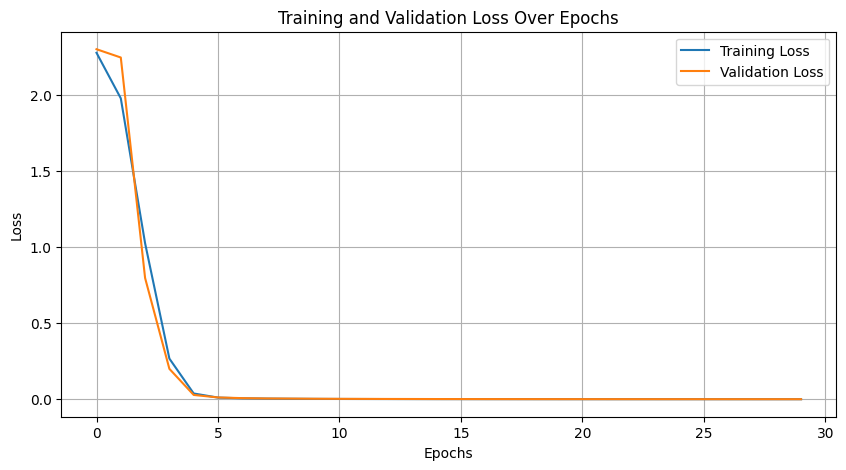

In [154]:

if __name__ == "__main__":
    # Configuration
    BATCH_SIZE = 30
    LEARNING_RATE = 0.0001
    EPOCHS = 30
    NUM_DIGIT=16
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


    train_size = int(0.8* len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

    # Initialize DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=credit_card_collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=credit_card_collate_fn)


    model = MOCNN(img_channel=1, num_class=10,num_digit=NUM_DIGIT).to(DEVICE)


    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)


    train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS, device=DEVICE,eval=True)

In [133]:
print(len(dataset))

1200


In [155]:
def evaluate_accuracy(model, val_loader, device, num_digit):

    model.eval() # Set model to evaluation mode

    correct_sequences = 0
    total_samples = 0

    print("Starting full validation evaluation...")

    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(val_loader):

            # 1. Move data to device
            images = images.to(device)
            targets = targets.to(device)

            # 2. Align target shape
            # Ensure we only compare the first 'num_digit' columns
            targets = targets[:, :num_digit]

            # 3. Get Model Predictions
            # preds_list is a list of tensors, one for each digit position
            preds_list = model(images)

            # 4. Convert Logits to Integers (Your logic)
            res = []
            for i in range(num_digit):
                # Get the class index with highest probability
                pred_digit = preds_list[:,i,:].argmax(dim=1)
                res.append(pred_digit)

            # Shape becomes: [Batch_Size, Num_Digit] (e.g., [16, 4])
            predicted_sequence = torch.stack(res).t()

            # 5. Check Strict Accuracy (The "All or Nothing" check)

            # Step A: Compare element-wise. Result is a Boolean matrix.
            # Example: [[True, True, True, True], [True, False, True, True]]
            matches = predicted_sequence.eq(targets)

            # Step B: Check if ALL items in a row are True.
            # dim=1 means "check along the columns for each row".
            # Result: [True, False] (Second image failed because of one digit)
            row_is_perfect = matches.all(dim=1)

            # Step C: Count the True values
            correct_sequences += row_is_perfect.sum().item()
            total_samples += images.size(0)

    # 6. Calculate Final Percentage
    accuracy = 100.0 * correct_sequences / total_samples

    print("-" * 30)
    print(f"Total Samples Checked: {total_samples}")
    print(f"Perfectly Predicted:   {correct_sequences}")
    print(f"Final Accuracy:        {accuracy:.2f}%")
    print("-" * 30)

    return accuracy

# --- Usage ---
# evaluate_accuracy(model, val_loader, device, num_digit=4)

In [156]:
evaluate_accuracy(model=model,val_loader=val_loader,device='cuda',num_digit=NUM_DIGIT)

Starting full validation evaluation...
------------------------------
Total Samples Checked: 240
Perfectly Predicted:   240
Final Accuracy:        100.00%
------------------------------


100.0

In [157]:
# Calculate the total number of parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params:,}")

# Calculate only trainable parameters (useful for fine-tuning)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters: 5,257,866
Trainable Parameters: 5,257,866
